# 1. Vytváření polí v NumPy

## 1.1 Import knihovny

Pro práci s knihovnou `numpy` ji obvykle importujeme pod aliasem `np`.


In [1]:
import numpy as np


## 1.2 Základní způsoby vytvoření pole

Pole v NumPy můžeme vytvořit několika běžnými způsoby:
- z Python kontejnerů (`list`, `tuple`),
- pomocí funkcí jako `zeros`, `ones`, `full`, `arange`, `linspace`,
- odvozením z existujících polí (výřezy, spojování, opakování, změna tvaru),
- načtením ze souboru (například `loadtxt`, `genfromtxt`).


## 1.3 Vytváření polí z Python kontejnerů


In [2]:
muj_list = [1, 2, 3, 4, 5]
A = np.array(muj_list)
print(A)
print(A.dtype)


[1 2 3 4 5]
int64


Vícerozměrné pole (matice) se vytvoří z vnořeného seznamu.

In [3]:
matrix = np.array([[1, 2], [3, 4]])
matrix


array([[1, 2],
       [3, 4]])

In [4]:
muj_tuple = (1, 2, 3, 4, 5)
A = np.array(muj_tuple)
print(A)
print(A.dtype)


[1 2 3 4 5]
int64


Ze `set` a `dict` vznikne při převodu na `np.array` jiný výsledek, než bychom často čekali.


In [5]:
muj_set = {1, 2, 3, 4, 5}
A = np.array(muj_set)
print(A)
print(type(A))
print(A.dtype)
print(A.shape)
print(A.size)
print(A.ndim)
print(A.itemsize)


{1, 2, 3, 4, 5}
<class 'numpy.ndarray'>
object
()
1
0
8


In [6]:
muj_dict = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
A = np.array(muj_dict)
print(A)
print(type(A))
print(A.dtype)
print(A.shape)
print(A.size)
print(A.ndim)
print(A.itemsize)


{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
<class 'numpy.ndarray'>
object
()
1
0
8


## 1.4 Funkce pro vytváření `ndarray`

Zejména větší pole je nepraktické inicializovat ručně. NumPy proto nabízí řadu funkcí pro rychlé vytvoření typických polí.


### 1.4.1 `arange`

`arange` vygeneruje posloupnost. Syntaxe je podobná `range`, ale funguje i pro desetinný krok.


In [7]:
np.arange(0, 10, 1)  # argumenty: start, stop, step


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [8]:
np.arange(-1, 0, 0.1)

array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1])

### 1.4.2 `linspace` a `logspace`

Obě funkce vytvářejí posloupnost s daným počtem prvků.


In [9]:
# první a poslední prvek jsou obsaženy ve výsledku
# argumenty jsou odkud, kam, kolik prvků
np.linspace(0, 10, 5)


array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [10]:
# podobně jako linspace, ale výsledek je base**x
np.logspace(0, 10, 11, base=10)


array([1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06, 1.e+07,
       1.e+08, 1.e+09, 1.e+10])

### 1.4.3 `ones`, `zeros` a `full`

`ones` a `zeros` vytvoří pole vyplněné jedničkami nebo nulami, `full` vyplní pole zadanou hodnotou.


In [11]:
np.ones(3)


array([1., 1., 1.])

In [12]:
# pokud chceme 2 a více rozměrů, musíme zadat rozměr jako tuple
np.zeros((2, 3))


array([[0., 0., 0.],
       [0., 0., 0.]])

In [13]:
# matice s string hodnotami pomocí np.full
np.full((2, 3), "hello world")

array([['hello world', 'hello world', 'hello world'],
       ['hello world', 'hello world', 'hello world']], dtype='<U11')

### 1.4.4 `meshgrid`, `mgrid` a `ogrid`

- `meshgrid` vytvoří pravidelnou mřížku souřadnic ze vstupních vektorů.
- `mgrid` používá zápis přes řezy (např. `np.mgrid[0:5, 0:5]`).
- `ogrid` je paměťově úsporná varianta, která vrací otevřenou mřížku vhodnou pro broadcasting.


In [14]:
# meshgrid
x = np.linspace(-1, 1, 4)
y = np.linspace(1, 2, 3)
X, Y = np.meshgrid(x, y)
print(X)
print(Y)


[[-1.         -0.33333333  0.33333333  1.        ]
 [-1.         -0.33333333  0.33333333  1.        ]
 [-1.         -0.33333333  0.33333333  1.        ]]
[[1.  1.  1.  1. ]
 [1.5 1.5 1.5 1.5]
 [2.  2.  2.  2. ]]


In [15]:
# všimněte si syntaxe s hranatými závorkami: mgrid se nevolá jako funkce
X, Y = np.mgrid[0:0.6:0.2, 0:0.6:0.2]
print(X)
print(Y)

Y, X = np.mgrid[1:2:3j, -1:1:4j]
print(X)
print(Y)


[[0.  0.  0. ]
 [0.2 0.2 0.2]
 [0.4 0.4 0.4]]
[[0.  0.2 0.4]
 [0.  0.2 0.4]
 [0.  0.2 0.4]]
[[-1.         -0.33333333  0.33333333  1.        ]
 [-1.         -0.33333333  0.33333333  1.        ]
 [-1.         -0.33333333  0.33333333  1.        ]]
[[1.  1.  1.  1. ]
 [1.5 1.5 1.5 1.5]
 [2.  2.  2.  2. ]]


In [16]:
# výstupy jsou řádkové a sloupcové vektory
y, x = np.ogrid[1:2:3j, -1:1:4j]
print(x)
print(y)


[[-1.         -0.33333333  0.33333333  1.        ]]
[[1. ]
 [1.5]
 [2. ]]


### 1.4.5 Náhodná data

Náhodná data vytváří funkce z modulu `np.random`.


In [17]:
# několik náhodných čísel [0, 1] s rovnoměrným rozdělením
print(np.random.rand(4,2))
# několik náhodných čísel s normálním rozdělením
print(np.random.randn(4,2))
# několik náhodných celých čísel
print(np.random.randint(0, 10, (4,2)))

[[0.40027062 0.37858104]
 [0.46204857 0.02741734]
 [0.31919819 0.62479361]
 [0.7610913  0.14310088]]
[[-1.27989689 -0.44680173]
 [ 1.41623111  0.94464073]
 [ 0.54413691  0.082193  ]
 [ 1.42424913  0.46467996]]
[[3 1]
 [8 5]
 [6 5]
 [8 5]]


### 1.4.6 Diagonály a trojúhelníkové části

`diagflat` vytvoří diagonální matici, `diagonal` vrátí diagonálu matice.


In [18]:
# diagonální matice
diag = np.diagflat([1, 2, 3])
print(diag)


[[1 0 0]
 [0 2 0]
 [0 0 3]]


In [19]:
# vrátí diagonálu jako vektor
print(np.diagonal(diag))


[1 2 3]


`np.triu` a `np.tril` vrací horní a dolní trojúhelníkovou část matice.

- `k=0` znamená hlavní diagonálu,
- `k>0` diagonálu nad hlavní,
- `k<0` diagonálu pod hlavní.


In [20]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(A)
print(np.triu(A, k=1))
print(np.tril(A, k=-1))


[[1 2 3]
 [4 5 6]
 [7 8 9]]
[[0 2 3]
 [0 0 6]
 [0 0 0]]
[[0 0 0]
 [4 0 0]
 [7 8 0]]


### 1.4.7 Spojování polí

Pole můžeme spojovat pomocí `concatenate`, `vstack` a `hstack`. Ve všech nelepících osách musí mít pole stejnou velikost.


In [21]:
A = np.array([[1, 2], [4, 5], [7, 8]])
B = np.array([[3, 4], [6, 7], [9, 10]])
print(A)
print(B)
print("----")
print(np.concatenate((A, B), axis=0))
print(np.concatenate((A, B), axis=1))
print("----")
print(np.vstack((A, B)))
print(np.hstack((A, B)))


[[1 2]
 [4 5]
 [7 8]]
[[ 3  4]
 [ 6  7]
 [ 9 10]]
----
[[ 1  2]
 [ 4  5]
 [ 7  8]
 [ 3  4]
 [ 6  7]
 [ 9 10]]
[[ 1  2  3  4]
 [ 4  5  6  7]
 [ 7  8  9 10]]
----
[[ 1  2]
 [ 4  5]
 [ 7  8]
 [ 3  4]
 [ 6  7]
 [ 9 10]]
[[ 1  2  3  4]
 [ 4  5  6  7]
 [ 7  8  9 10]]


## 1.5 Opakování polí

Na opakování slouží funkce `repeat` a `tile`.


In [22]:
a = np.array([[1, 2], [3, 4]])
a


array([[1, 2],
       [3, 4]])

In [23]:
# opakování po prvcích
np.repeat(a, 3)


array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4])

In [24]:
# skládání celých polí
np.tile(a, (3, 2))


array([[1, 2, 1, 2],
       [3, 4, 3, 4],
       [1, 2, 1, 2],
       [3, 4, 3, 4],
       [1, 2, 1, 2],
       [3, 4, 3, 4]])

## 1.6 Změna rozměrů polí

Tvar NumPy pole můžeme měnit například funkcí `reshape`.


In [25]:
m1 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(m1)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [26]:
n, m = m1.shape
print(m,n)

3 3


Například takto vytvoříme 2D řádkový vektor:


In [27]:
m2 = m1.reshape((1, n * m))
print(m2)
print(m2.shape)

[[1 2 3 4 5 6 7 8 9]]
(1, 9)


Nebo použít -1 pro automatické dopočítání

In [28]:
m1.reshape((1, -1))


array([[1, 2, 3, 4, 5, 6, 7, 8, 9]])

Pokud chceme skutečné 1D pole, můžeme použít:
- `reshape`
- `flatten`
- `ravel`


In [29]:
m2 = m1.reshape((n * m))
print(m2)
# nebo
m2 = m1.reshape((-1))
print(m2)
# nebo
m2 = m1.flatten() 
print(m2)
# nebo 
m2 = m1.ravel()
print(m2)


[1 2 3 4 5 6 7 8 9]
[1 2 3 4 5 6 7 8 9]
[1 2 3 4 5 6 7 8 9]
[1 2 3 4 5 6 7 8 9]


## 1.7 Přidávání dimenzí: `newaxis`

Pomocí `newaxis` lze přes řezy jednoduše přidat rozměr (například převod 1D vektoru na sloupcový/řádkový).

`newaxis` je jen čitelnější zápis pro `None`.


In [30]:
v = np.array([1, 2, 3])
v.shape


(3,)

In [31]:
# vytvoříme sloupec
vc = v[:, np.newaxis]
vc


array([[1],
       [2],
       [3]])

In [32]:
vc = v[:, None]
print(vc)


[[1]
 [2]
 [3]]


In [33]:
vc.shape


(3, 1)

## 1.8 Základní vykreslování pomocí Matplotlib

Matplotlib je knihovna pro vykreslování grafů v Pythonu. S NumPy spolupracuje přímo, takže lze pole snadno vizualizovat.


In [35]:
import matplotlib.pyplot as plt

### 1.8.1 Graf a obrázek

Ukážeme si úplný základ:
- jednoduchý graf přes `plt.plot()`,
- zobrazení matice jako obrázku přes `plt.imshow()`.


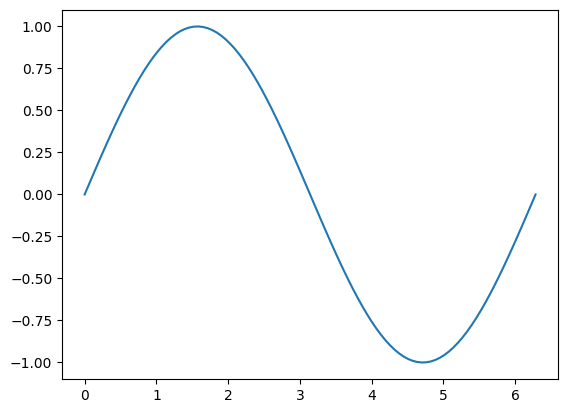

In [44]:
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)
A = np.random.random((100, 100))

plt.plot(x, y)

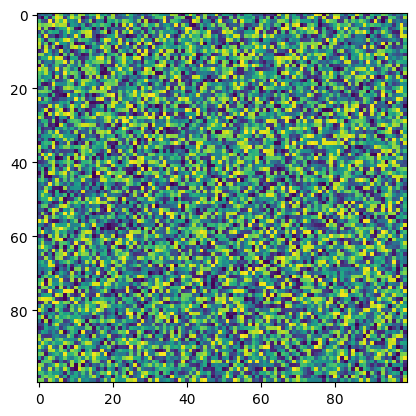

In [48]:
plt.imshow(A)